# UCI Heart Disease - Exploratory Data Analysis & Modeling

This notebook demonstrates the full data science lifecycle natively in Jupyter:
1. **Exploratory Data Analysis (EDA):** Understanding the clinical features and relationships.
2. **Modeling:** Building a strongly constrained Multilayer Perceptron.
3. **Evaluation:** Comparing Train vs Test performance and using Monte Carlo Dropout to measure prediction uncertainty.


In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_and_clean, split_and_scale
from src.model import build_model, mc_predict

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


I0000 00:00:1775529175.890431   80473 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775529175.935122   80473 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775529177.379958   80473 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Exploratory Data Analysis (EDA)

Before building our model, we should explore our clinical variables to find patterns and correlations between patient attributes and heart disease.


In [2]:
print("Loading unprocessed data for EDA...")
# load_and_clean() automatically downloads the data if missing and fills missing values.
df = load_and_clean()
df.head()


Loading unprocessed data for EDA...


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


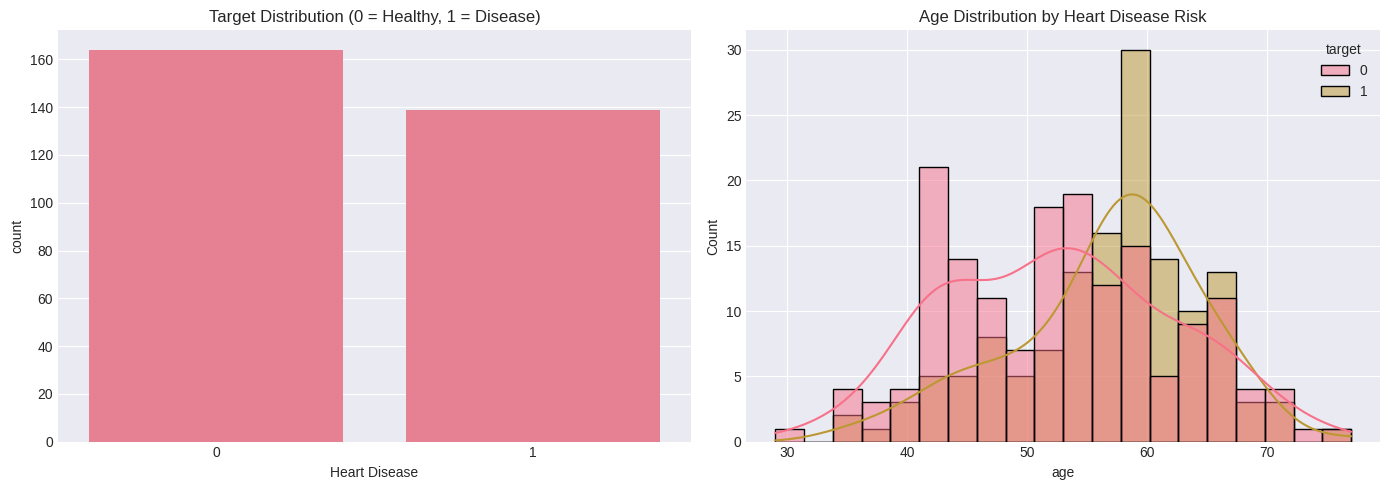

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Target Distribution
sns.countplot(data=df, x='target', ax=ax[0])
ax[0].set_title("Target Distribution (0 = Healthy, 1 = Disease)")
ax[0].set_xlabel("Heart Disease")

# Age Distribution
sns.histplot(data=df, x='age', bins=20, kde=True, hue='target', ax=ax[1])
ax[1].set_title("Age Distribution by Heart Disease Risk")

plt.tight_layout()
plt.show()


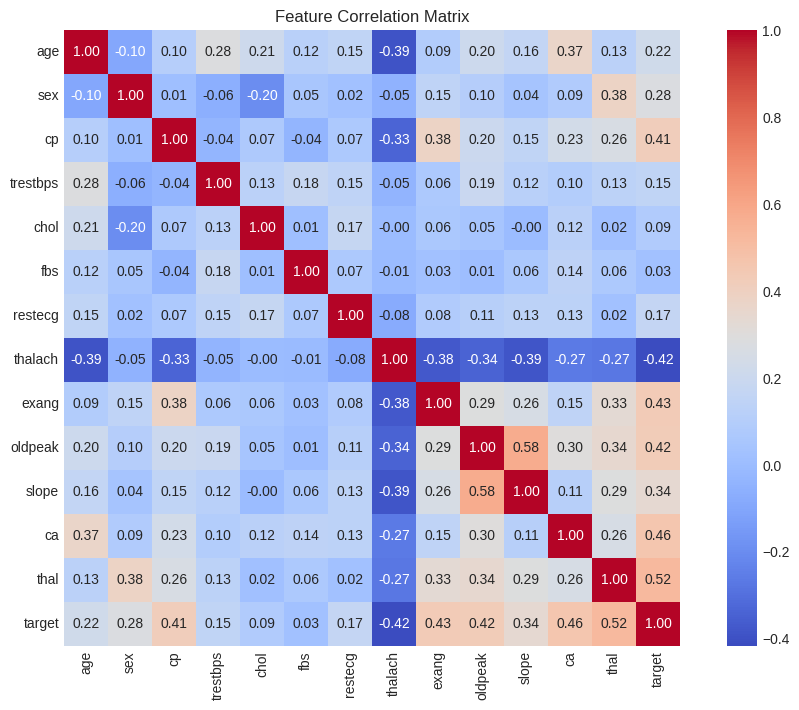

Features highly correlated with target:
target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [4]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Feature Correlation Matrix")
plt.show()

print("Features highly correlated with target:")
print(corr['target'].sort_values(ascending=False))


## 2. Data Preparation & Model Building

Now we properly split our data into Training and Test sets using `split_and_scale()`, and build our strictly constrained Neural Network architecture to avoid overfitting.


In [ ]:
data_dict = split_and_scale(df)

X_train = data_dict['X_train_scaled']
X_test = data_dict['X_test_scaled']
y_train = data_dict['y_train']
y_test = data_dict['y_test']

print(f"Train set: {X_train.shape[0]} patients, Test set: {X_test.shape[0]} patients.")


Train set: 242 patients, Test set: 61 patients.


In [ ]:
model = build_model(
    input_dim=X_train.shape[1],
    hidden_layers=[16],          #
    dropout_rate=0.5,            
    max_norm_value=0.5           
)

model.summary()


E0000 00:00:1775529178.598523   80473 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775529178.599142   80577 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775529178.612005   80473 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "HeartDisease_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patient_features (InputLayer)   │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swish_0 (Activation)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_0 (MCDropout)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 32 (128.00 B)

## 3. Training & Evaluation
We will use an `EarlyStopping` callback to guarantee we save the best model weights dynamically.


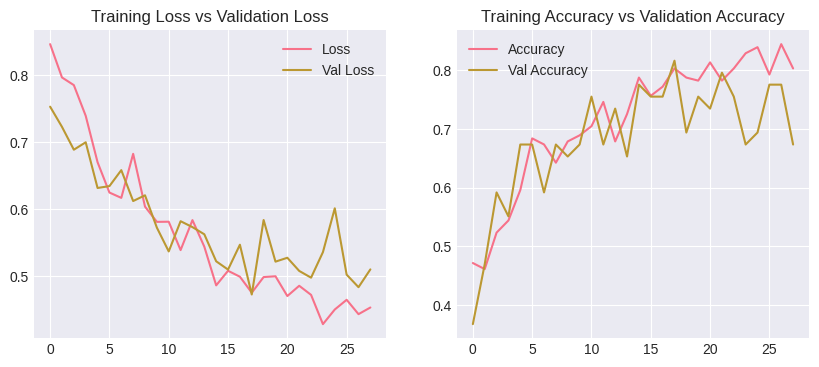

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10,             
    restore_best_weights=True 
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stopping]
)

def plot_history(history):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Training Loss vs Validation Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title('Training Accuracy vs Validation Accuracy')
    plt.show()

plot_history(history)


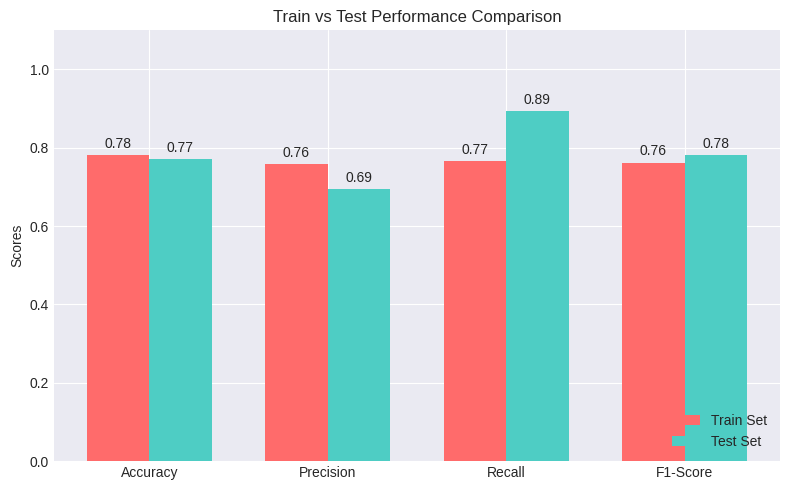

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred = (model.predict(X_train, verbose=0) >= 0.5).astype(int)
y_test_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int)

def get_metrics(y_t, y_p):
    return [
        accuracy_score(y_t, y_p),
        precision_score(y_t, y_p, zero_division=0),
        recall_score(y_t, y_p, zero_division=0),
        f1_score(y_t, y_p, zero_division=0)
    ]

train_metrics = get_metrics(y_train, y_train_pred)
test_metrics = get_metrics(y_test, y_test_pred)

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, train_metrics, width, label='Train Set', color='#ff6b6b')
rects2 = ax.bar(x + width/2, test_metrics, width, label='Test Set', color='#4ecdc4')

ax.set_ylabel('Scores')
ax.set_title('Train vs Test Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 4. Monte Carlo Inference
Measuring uncertainty for individual patient predictions.


In [ ]:
mean_preds, std_preds = mc_predict(model, X_test[:5])

print("--- Patient Uncertainty Diagnostics ---")
for i in range(5):
    m_val = float(mean_preds[i].item() if hasattr(mean_preds[i], 'item') else mean_preds[i])
    s_val = float(std_preds[i].item() if hasattr(std_preds[i], 'item') else std_preds[i])
    print(f"Patient {i}: Mean Risk = {m_val:.4f}, Uncertainty (Std Dev) = {s_val:.4f}, True Label = {y_test.iloc[i]}")


--- Patient Uncertainty Diagnostics ---
Patient 0: Mean Risk = 0.4573, Uncertainty (Std Dev) = 0.0753, True Label = 0
Patient 1: Mean Risk = 0.7071, Uncertainty (Std Dev) = 0.1000, True Label = 0
Patient 2: Mean Risk = 0.2468, Uncertainty (Std Dev) = 0.0716, True Label = 0
Patient 3: Mean Risk = 0.1988, Uncertainty (Std Dev) = 0.1691, True Label = 0
Patient 4: Mean Risk = 0.4840, Uncertainty (Std Dev) = 0.0530, True Label = 0
